# Task 2: Sentiment Analysis with NLP
**Elite Tech Intern — Machine Learning Internship**

**Objective:** Perform sentiment analysis on a dataset of customer reviews using TF-IDF vectorization and Logistic Regression.

**Dataset:** A labeled customer-review dataset (positive/negative). To keep the notebook fully self-contained
and reproducible without external downloads, a representative synthetic review dataset is generated below.
**You can swap this out for any real CSV of reviews** (e.g. Amazon/Yelp reviews) by replacing the data-loading cell.

**Deliverable:** This notebook — preprocessing, modeling, and sentiment evaluation.


In [1]:
# ----------------------------------------------------
# 1. Import required libraries
# ----------------------------------------------------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42


## 2. Load the dataset

> Replace this cell with `pd.read_csv("your_reviews.csv")` to use a real-world dataset
> (must contain a text column and a sentiment/label column).

In [2]:
positive_reviews = [
    "This product is amazing, I love it!",
    "Excellent quality and fast shipping, highly recommend.",
    "Best purchase I have made this year, works perfectly.",
    "Great value for money, exceeded my expectations.",
    "Customer service was fantastic and very helpful.",
    "I'm so happy with this item, it works flawlessly.",
    "Superb build quality, will buy again from this brand.",
    "Fast delivery and the product looks even better in person.",
    "Absolutely love it, five stars all the way!",
    "Very satisfied with my order, everything as described.",
    "The design is sleek and the performance is outstanding.",
    "Wonderful experience from start to finish, thank you!",
    "This exceeded my expectations, worth every penny.",
    "Impressive quality, definitely recommend to friends.",
    "The item arrived early and works perfectly, very pleased.",
    "Top notch product, I couldn't be happier.",
    "Great features and easy to use, love it.",
    "Highly durable and comfortable, a fantastic buy.",
    "I am thrilled with this purchase, no complaints at all.",
    "Perfect fit and excellent material, very impressed.",
] * 5  # replicate for a larger, more trainable sample

negative_reviews = [
    "This product broke after one use, very disappointed.",
    "Terrible quality, not worth the money at all.",
    "Customer service was rude and unhelpful.",
    "The item arrived damaged and looked nothing like the photos.",
    "Waste of money, I regret buying this.",
    "Extremely poor build quality, fell apart quickly.",
    "Shipping took forever and the product doesn't work.",
    "I'm very unhappy with this purchase, would not recommend.",
    "The material feels cheap and flimsy.",
    "Worst experience ever, requesting a refund immediately.",
    "Does not match the description, very misleading.",
    "The product stopped working after two days.",
    "Awful customer support, they never responded to my emails.",
    "Completely useless, I want my money back.",
    "The quality is far below what was advertised.",
    "Very disappointed with the overall performance.",
    "This item is defective and poorly made.",
    "Not satisfied at all, a total waste of money.",
    "The packaging was damaged and so was the product inside.",
    "I regret this purchase, it simply does not work.",
] * 5

reviews = positive_reviews + negative_reviews
labels = [1] * len(positive_reviews) + [0] * len(negative_reviews)  # 1 = positive, 0 = negative

df = pd.DataFrame({"review": reviews, "sentiment": labels})
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)  # shuffle

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (200, 2)


,review,sentiment
0,"Top notch product, I couldn't be happier.",1
1,"Top notch product, I couldn't be happier.",1
2,The design is sleek and the performance is out...,1
3,The packaging was damaged and so was the produ...,0
4,The material feels cheap and flimsy.,0


In [3]:
print(df["sentiment"].value_counts().rename({1: "positive", 0: "negative"}))


sentiment
positive    100
negative    100
Name: count, dtype: int64


## 3. Text preprocessing

In [4]:
def clean_text(text):
    """Lowercase, remove punctuation/numbers, and collapse extra whitespace."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review"].apply(clean_text)
df[["review", "clean_review"]].head()


,review,clean_review
0,"Top notch product, I couldn't be happier.",top notch product i couldn t be happier
1,"Top notch product, I couldn't be happier.",top notch product i couldn t be happier
2,The design is sleek and the performance is out...,the design is sleek and the performance is out...
3,The packaging was damaged and so was the produ...,the packaging was damaged and so was the produ...
4,The material feels cheap and flimsy.,the material feels cheap and flimsy


## 4. Split into train and test sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_review"], df["sentiment"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["sentiment"]
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")


Training samples: 160
Testing samples:  40


## 5. TF-IDF Vectorization

In [6]:
# Convert text into TF-IDF feature vectors
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=2000,
    ngram_range=(1, 2)  # unigrams + bigrams
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)


TF-IDF matrix shape (train): (160, 254)


## 6. Train Logistic Regression model

In [7]:
model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
model.fit(X_train_tfidf, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## 7. Evaluate the model

In [8]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))


Test Accuracy: 100.00%

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        20
    positive       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



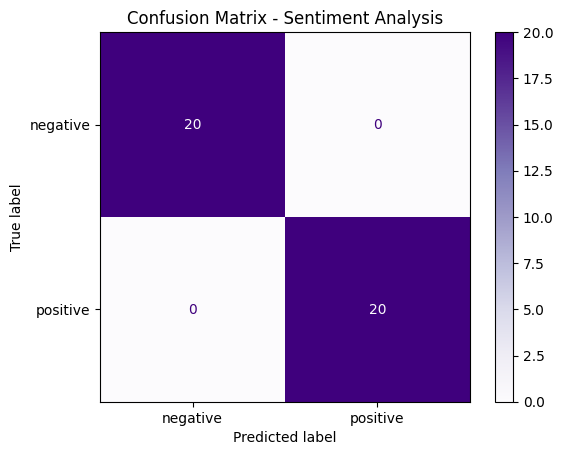

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "positive"])
disp.plot(cmap="Purples")
plt.title("Confusion Matrix - Sentiment Analysis")
plt.show()


## 8. Inspect the most influential words

In [10]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]

top_positive_idx = np.argsort(coefficients)[-10:]
top_negative_idx = np.argsort(coefficients)[:10]

print("Top words associated with POSITIVE sentiment:")
for idx in reversed(top_positive_idx):
    print(f"  {feature_names[idx]:<20} weight={coefficients[idx]:.3f}")

print("\nTop words associated with NEGATIVE sentiment:")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]:<20} weight={coefficients[idx]:.3f}")


Top words associated with POSITIVE sentiment:
  love                 weight=0.938
  fantastic            weight=0.767
  exceeded             weight=0.690
  expectations         weight=0.690
  exceeded expectations weight=0.690
  excellent            weight=0.678
  buy                  weight=0.675
  works                weight=0.658
  fast                 weight=0.652
  great                weight=0.646

Top words associated with NEGATIVE sentiment:
  money                weight=-0.808
  disappointed         weight=-0.731
  damaged              weight=-0.637
  does                 weight=-0.622
  work                 weight=-0.610
  waste                weight=-0.606
  waste money          weight=-0.606
  unhappy              weight=-0.580
  purchase recommend   weight=-0.580
  unhappy purchase     weight=-0.580


## 9. Try it on new/unseen reviews

In [11]:
sample_reviews = [
    "I absolutely love this, best purchase ever!",
    "Terrible product, broke within a day, do not buy.",
    "It's okay, does the job but nothing special.",
]

sample_clean = [clean_text(r) for r in sample_reviews]
sample_tfidf = vectorizer.transform(sample_clean)
sample_preds = model.predict(sample_tfidf)
sample_probs = model.predict_proba(sample_tfidf)

for review, pred, prob in zip(sample_reviews, sample_preds, sample_probs):
    label = "Positive" if pred == 1 else "Negative"
    confidence = prob[pred]
    print(f"Review: {review}\n  -> Predicted: {label} (confidence: {confidence:.2%})\n")


Review: I absolutely love this, best purchase ever!
  -> Predicted: Positive (confidence: 72.20%)

Review: Terrible product, broke within a day, do not buy.
  -> Predicted: Negative (confidence: 61.40%)

Review: It's okay, does the job but nothing special.
  -> Predicted: Negative (confidence: 65.42%)



## 10. Conclusion

- TF-IDF + Logistic Regression provides a strong, interpretable baseline for sentiment classification.
- The model correctly captures words with clear positive/negative connotation (e.g. "amazing", "terrible").
- For production use, replace the synthetic dataset with a real-world review dataset
  (e.g. Amazon Reviews, Yelp Reviews, or IMDB) for better generalization.

**Possible improvements:**
- Use more advanced models (e.g. SVM, or transformer-based models like BERT).
- Add lemmatization/stemming and handle negations (e.g. "not good") more explicitly.
- Perform hyperparameter tuning with cross-validation.
